<a href="https://colab.research.google.com/github/Dulyana-Silva/MLproject6-Stock-Trend-Prediction/blob/main/Stock_Trend_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas_datareader as data

In [36]:
import yfinance as yf
import datetime as dt

stock = "POWERGRID.NS"
start = dt.datetime(2000, 1, 1)
end = dt.datetime(2026, 6, 1)

df = yf.download(stock, start, end)

/tmp/ipykernel_735/1347634669.py:8: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


In [37]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
Date,,,,,
2007-10-05,30.896236,33.629602,25.536998,27.579345,855215656
2007-10-08,29.314573,31.940446,29.130301,31.940446,126671715
2007-10-09,31.310860,31.587267,27.748271,29.329936,116725709
2007-10-10,31.602602,32.247554,31.326195,32.124705,67931378
2007-10-11,35.134487,36.854358,31.326205,36.854358,106320954


Data is starting from **2007**.

We asked for data from 2000, since it gave starting from 2007, that's means yfinance only has data from 2007.

In [38]:
df.tail()

Price,Close,High,Low,Open,Volume
Ticker,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
Date,,,,,
2026-05-25,295.350006,298.500000,294.149994,298.500000,5896815
2026-05-26,292.549988,295.950012,292.049988,295.000000,5625947
2026-05-27,300.149994,301.250000,292.000000,292.000000,9883025
2026-05-28,300.149994,300.149994,300.149994,300.149994,0
2026-05-29,290.549988,303.000000,285.450012,303.000000,77407363


In [39]:
df.shape

(4598, 5)

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4598 entries, 2007-10-05 to 2026-05-29
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   (Close, POWERGRID.NS)   4598 non-null   float64
 1   (High, POWERGRID.NS)    4598 non-null   float64
 2   (Low, POWERGRID.NS)     4598 non-null   float64
 3   (Open, POWERGRID.NS)    4598 non-null   float64
 4   (Volume, POWERGRID.NS)  4598 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 215.5 KB


In [41]:
df.isnull().sum()

,,0
Price,Ticker,
Close,POWERGRID.NS,0
High,POWERGRID.NS,0
Low,POWERGRID.NS,0
Open,POWERGRID.NS,0
Volume,POWERGRID.NS,0


There's No any null values.

In [42]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
count,4598.000000,4598.000000,4598.000000,4598.000000,4.598000e+03
mean,93.773844,94.943077,92.618616,93.821073,1.199055e+07
std,83.032255,83.943007,82.093907,83.050471,1.984763e+07
min,18.038849,19.282907,16.172761,19.189602,0.000000e+00
25%,35.328309,35.849248,34.828865,35.379366,5.030466e+06
50%,65.839470,66.743185,64.921291,65.924906,8.693871e+06
75%,109.070290,111.024434,107.576961,109.063493,1.391070e+07
max,344.843262,345.598137,337.058457,343.522181,8.552157e+08


In [43]:
# Adding the index column
df = df.reset_index()

In [44]:
# New number of colums --> 6
df.shape

(4598, 6)

In [45]:
df.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
0,2007-10-05,30.896236,33.629602,25.536998,27.579345,855215656
1,2007-10-08,29.314573,31.940446,29.130301,31.940446,126671715
2,2007-10-09,31.310860,31.587267,27.748271,29.329936,116725709
3,2007-10-10,31.602602,32.247554,31.326195,32.124705,67931378
4,2007-10-11,35.134487,36.854358,31.326205,36.854358,106320954


Now the index column is visible.

In [46]:
df.columns

MultiIndex([(  'Date',             ''),
            ( 'Close', 'POWERGRID.NS'),
            (  'High', 'POWERGRID.NS'),
            (   'Low', 'POWERGRID.NS'),
            (  'Open', 'POWERGRID.NS'),
            ('Volume', 'POWERGRID.NS')],
           names=['Price', 'Ticker'])

In [58]:
#candlesticks --> Type of price chart used in technical analysis.
import plotly.graph_objects as go

fig = go.Figure(data = [go.Candlestick(x = df['Date'], open= df['Open'], high = df['High'], low=df['Low'], close = df['Close'])])

fig.update_layout(xaxis_rangeslider_visible = False)

fig.show()

In [53]:
data01 = df.to_csv("powergrid.csv")

In [54]:
data01 = pd.read_csv("powergrid.csv")

In [55]:
data01.head()

,Price,Date,Close,High,Low,Open,Volume
0,Ticker,NaN,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
1,0,2007-10-05,30.896236419677734,33.62960189509571,25.536998153531204,27.579344583114715,855215656
2,1,2007-10-08,29.314573287963867,31.940446244514217,29.13030069765617,31.940446244514217,126671715
3,2,2007-10-09,31.31085968017578,31.587266562499465,27.74827051473354,29.32993605329764,116725709
4,3,2007-10-10,31.602602005004883,32.24755374642532,31.326195305988854,32.12470470469476,67931378


**Now it's a one DataFrame.**

In [59]:
#candlesticks --> Type of price chart used in technical analysis.
import plotly.graph_objects as go

fig = go.Figure(data = [go.Candlestick(x = data01['Date'], open= data01['Open'], high = data01['High'], low=data01['Low'], close = data01['Close'])])

fig.update_layout(xaxis_rangeslider_visible = False)

fig.show()

Now we got the **Candlestick plot.**

In [60]:
df = df.drop(['Date'], axis = 1)

/tmp/ipykernel_735/1002300862.py:1: PerformanceWarning:

dropping on a non-lexsorted multi-index without a level parameter may impact performance.



In [61]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
0,30.896236,33.629602,25.536998,27.579345,855215656
1,29.314573,31.940446,29.130301,31.940446,126671715
2,31.310860,31.587267,27.748271,29.329936,116725709
3,31.602602,32.247554,31.326195,32.124705,67931378
4,35.134487,36.854358,31.326205,36.854358,106320954


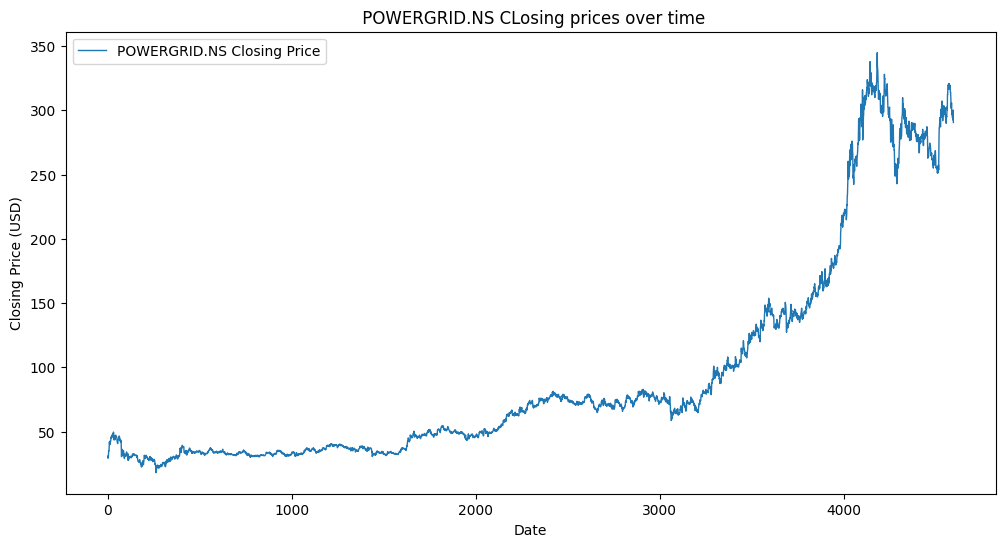

In [65]:
# For CLosing prices over time

plt.figure(figsize= (12, 6))
plt.plot(df['Close'], label = f'{stock} Closing Price', linewidth = 1)
plt.title(f' {stock} CLosing prices over time')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.legend()
plt.show()

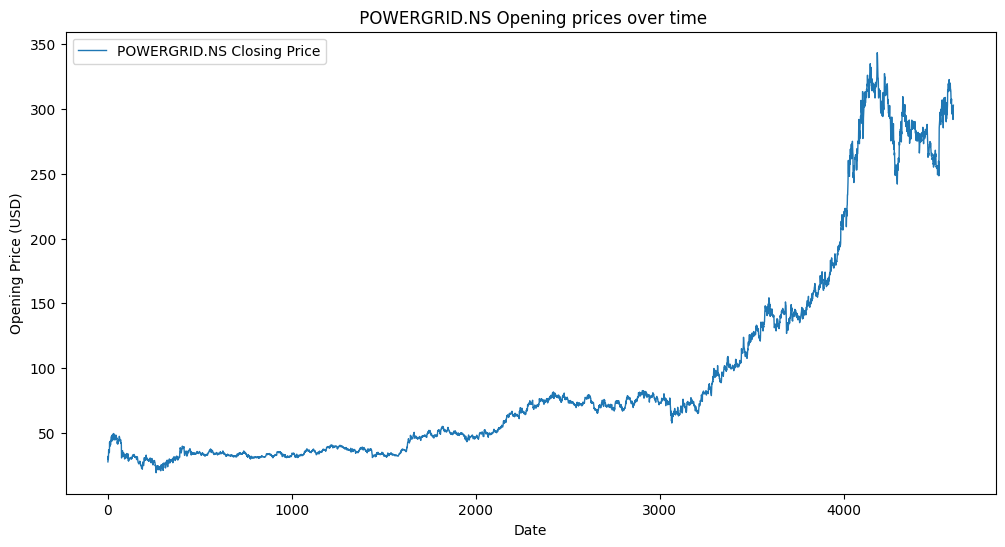

In [68]:
# For Opening prices over time

plt.figure(figsize= (12, 6))
plt.plot(df['Open'], label = f'{stock} Closing Price', linewidth = 1)
plt.title(f' {stock} Opening prices over time')
plt.xlabel('Date')
plt.ylabel('Opening Price (USD)')
plt.legend()
plt.show()

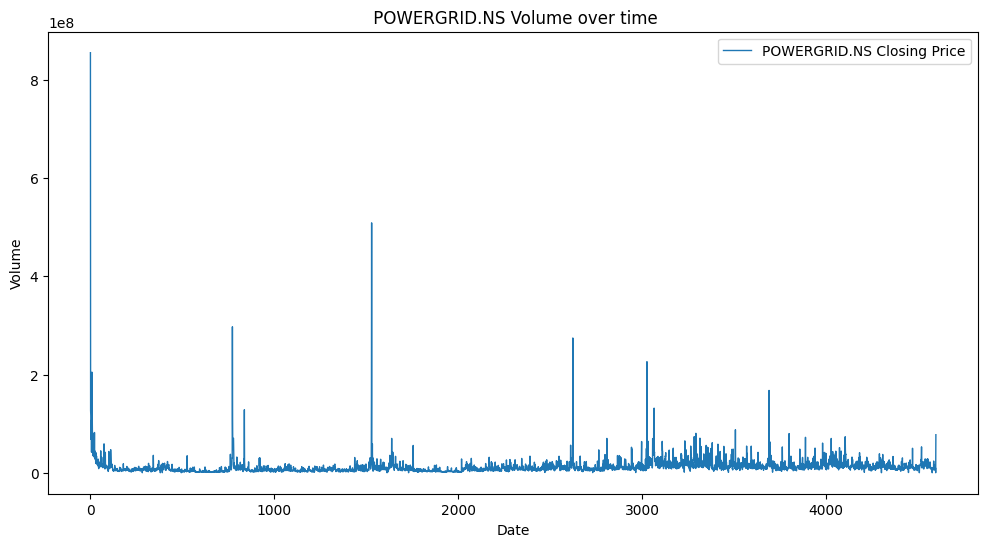

In [69]:
# For Volume over time

plt.figure(figsize= (12, 6))
plt.plot(df['Volume'], label = f'{stock} Closing Price', linewidth = 1)
plt.title(f' {stock} Volume over time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.legend()
plt.show()